In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [2]:
%config InlineBackend.figure_format = 'retina'

import random
import numpy as np
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from nsppk import NSPPK

from abstractgraph.operators import *
from abstractgraph_graphicalizer.chem import ZINCLoader, draw_molecules as display_graphs
from abstractgraph_ml.estimators import GraphEstimator
from abstractgraph_ml.feasibility import (
    FeasibilityEstimator,
    FeasibilityEstimatorFeatureCannotExist,
)
from abstractgraph_generative.edge_generator import EdgeGenerator


/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.2.0)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


In [3]:
loader = ZINCLoader(on_error="skip")

dataset_name = "zinc_250k"
size = 1000
min_num_nodes = 10
max_num_nodes = 13
USE_TARGETS = False

graphs, metadata = loader.load(
    dataset_name,
    limit=size,
    min_node_count=min_num_nodes,
    max_node_count=max_num_nodes,
)
targets = [max(dict(graph.degree()).values(), default=0) for graph in graphs] if USE_TARGETS else None

print(f"dataset: {dataset_name}")
print(f"n_graphs: {len(graphs)}")
print(f"node_range: [{min_num_nodes}, {max_num_nodes}]")
if USE_TARGETS:
    print("target: max_degree")
else:
    print("targets disabled")


dataset: zinc_250k
n_graphs: 1000
node_range: [10, 13]
targets disabled


In [4]:
nbits = 19
vectorizer = NSPPK(radius=1, distance=4, connector=1, nbits=14, parallel=True)

feasibility_kwargs = dict(
    nbits=nbits,
    parallel=True,
    backend="loky",
    n_jobs=-1,
)
feasibility_estimators = [
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(neighborhood(radius=2), unlabel()),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=path(number_of_edges=2),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=neighborhood(radius=1),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=cycle(),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(combination(number_of_elements=(2, 3), distance=0), cycle(), unlabel()),
        **feasibility_kwargs,
    ),
]
feasibility_estimator = FeasibilityEstimator(feasibility_estimators)

graph_estimator = GraphEstimator(
    transformer=vectorizer,
    estimator=RandomForestClassifier(
        random_state=0,
        n_estimators=300,
        n_jobs=-1,
        class_weight="balanced_subsample",
    ),
)

target_estimator = None
if USE_TARGETS:
    target_estimator = GraphEstimator(
        transformer=NSPPK(radius=1, distance=4, connector=1, nbits=14, parallel=True),
        estimator=RandomForestRegressor(
            random_state=0,
            n_estimators=300,
            n_jobs=-1,
        ),
    )

generator = EdgeGenerator(
    feasibility_estimator,
    graph_estimator,
    target_estimator=target_estimator,
    target_estimator_mode="regression",
    decomposition_function=add(cycle(), tree()),
    enforce_diversity=False,
    n_negative_per_positive=3,
    n_replicates=3,
    beam_size=2,
    fit_n_jobs=-1,
    fit_backend="loky",
    verbose=True,
    seed=0,
)


In [5]:
%%time
generator.store(graphs, targets=targets)
print(f"stored_graphs = {len(generator.stored_graphs_)}")


stored_graphs = 1000
CPU times: user 4.23 s, sys: 338 ms, total: 4.57 s
Wall time: 7.92 s


graph_a_idx = 583
graph_b_idx = 536
pair_target = None


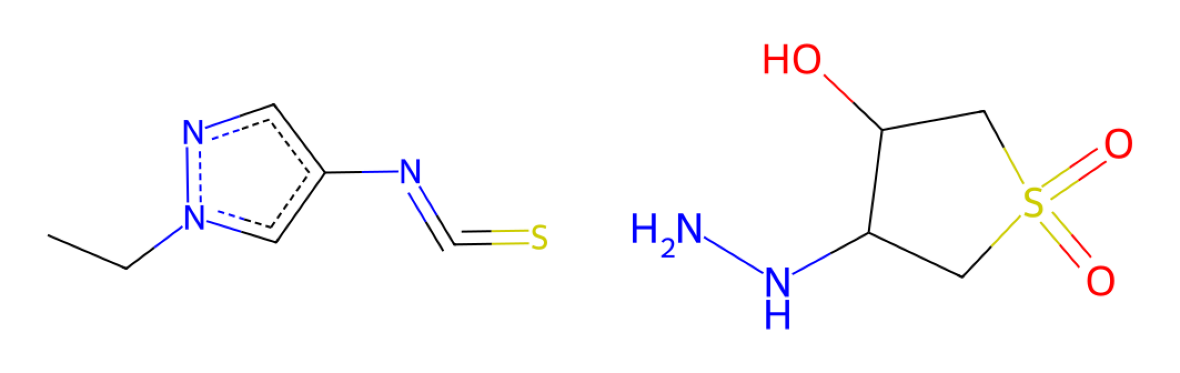

In [6]:
idx_a, idx_b = random.sample(range(len(graphs)), k=2)
graph_a = graphs[idx_a]
graph_b = graphs[idx_b]
pair_target = None
if USE_TARGETS:
    pair_target = int(round(np.mean([targets[idx_a], targets[idx_b]])))

print(f"graph_a_idx = {idx_a}")
print(f"graph_b_idx = {idx_b}")
print(f"pair_target = {pair_target}")
_ = display_graphs([graph_a, graph_b], n_graphs_per_line=2)


[pair] source_idx=583 dest_idx=536 n_paths=4 selected_graphs=5 path_lengths=[2, 3, 3, 3]
[pair] selected_indices=[203, 524, 536, 583, 765]
[pair] path 1/4 indices=[583, 536]


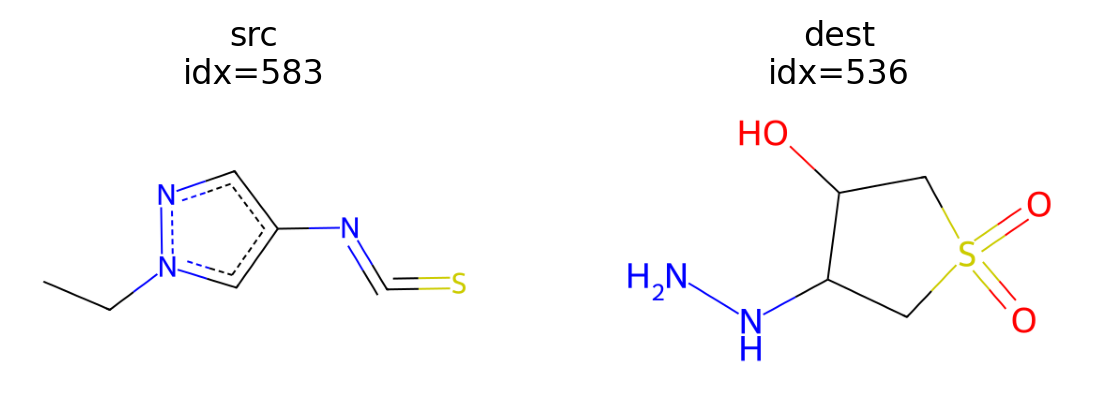

[pair] path 2/4 indices=[583, 524, 536]


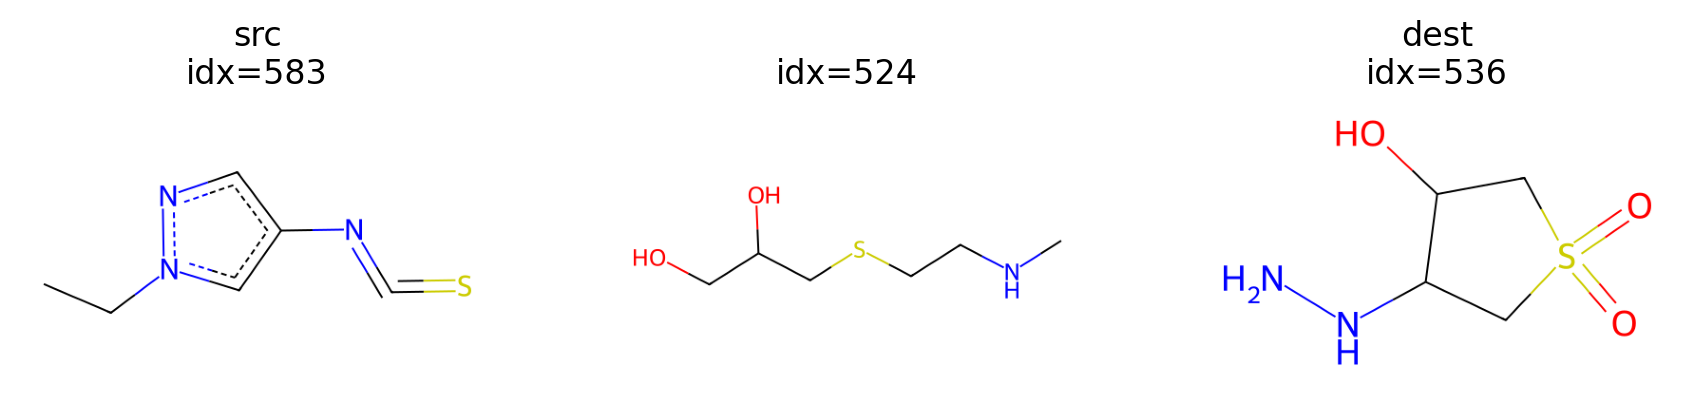

[pair] path 3/4 indices=[583, 765, 536]


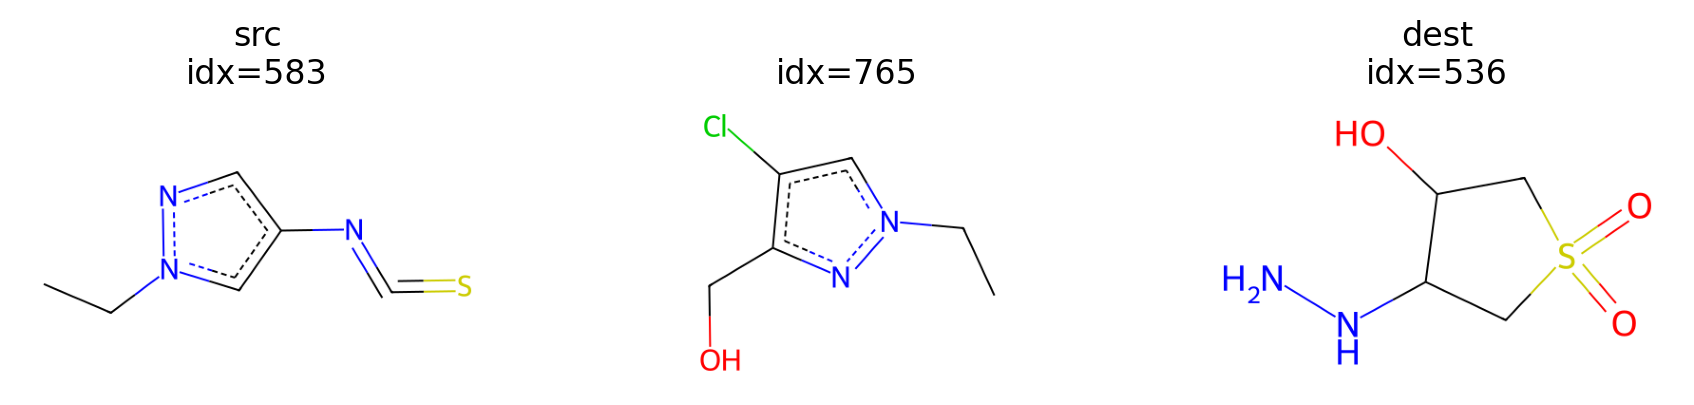

[pair] path 4/4 indices=[583, 203, 536]


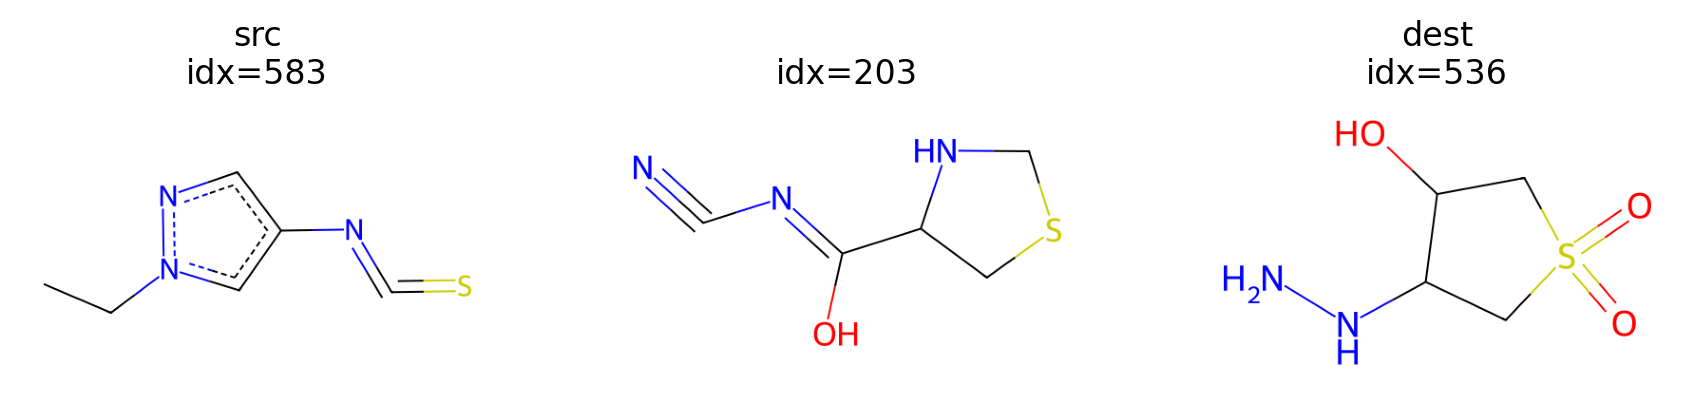

[fit] feasibility_graphs=122 positives=147 negatives=396 dataset=543 time=0m 5.1s
[fit] graph_estimator_graphs=543 positive_labels=147 negative_labels=396 time=0m 5.5s
[graph 0] start start_edges=0 target_edges=10 remaining_edges=10 target=None target_lambda=0.500


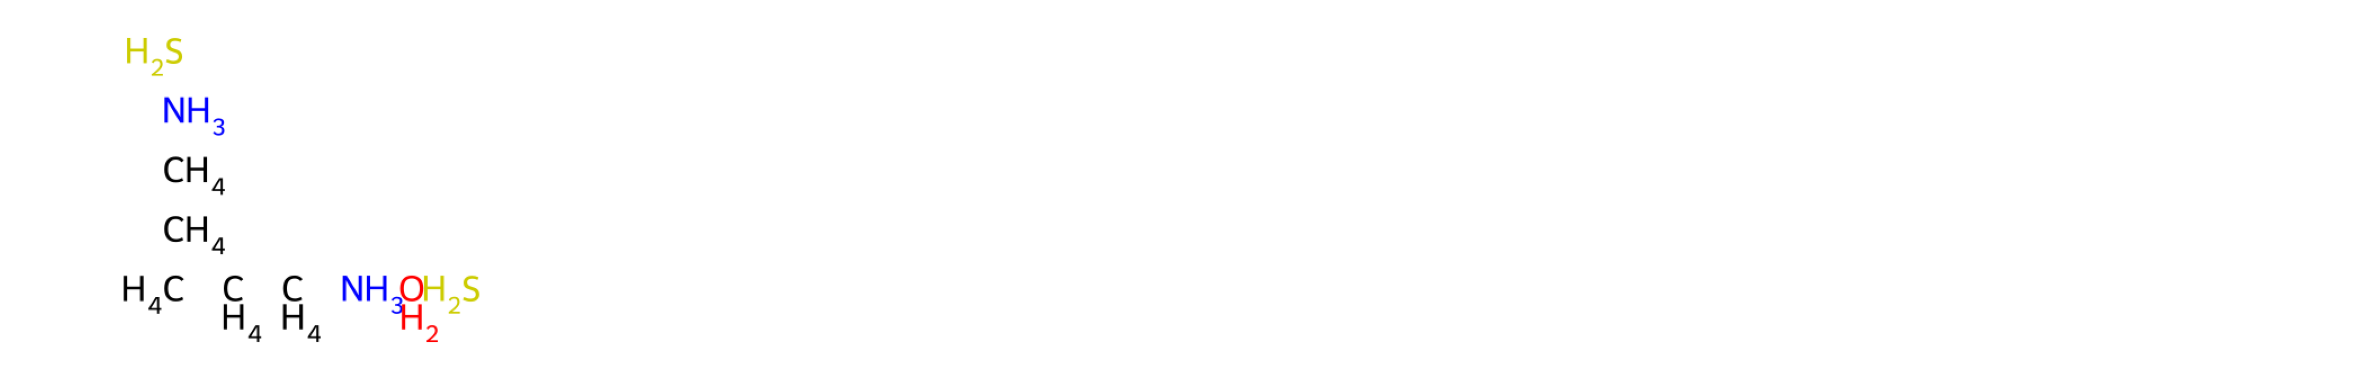

[graph 0] phase=1/4 beam_limit=2 fallback=0/3
[graph 0] phase=1/4 depth=1 remaining_edges=9 step_time=0m 16.0s eta=2m 23.6s
generated=180 feasible=89 retained=2 tried=180
best_score=0.679 best_target_score=0.000 best_selection_score=0.679 best_repulsion=0.000
target_lambda=0.500 repulsion_lambda=0.000 beam_limit=2


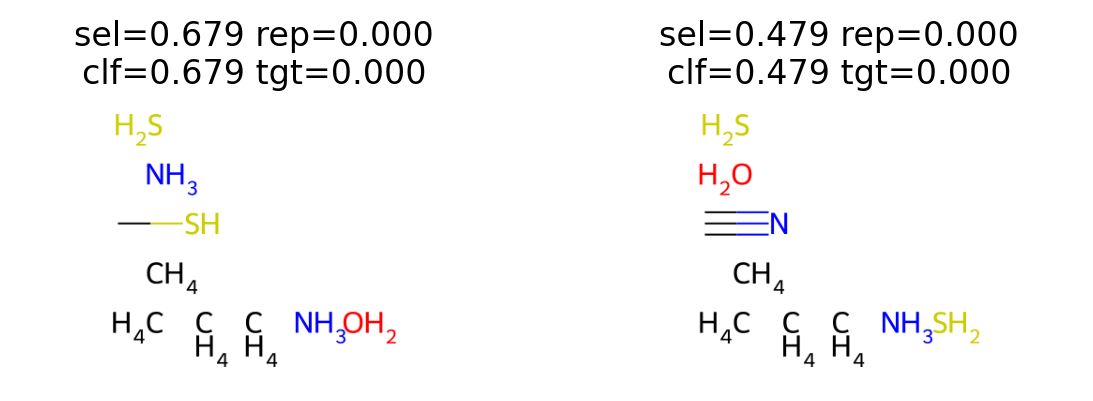

[graph 0] phase=1/4 depth=2 remaining_edges=8 step_time=0m 25.9s eta=3m 27.4s
generated=352 feasible=120 retained=2 tried=532
best_score=0.562 best_target_score=0.000 best_selection_score=0.562 best_repulsion=0.000
target_lambda=0.500 repulsion_lambda=0.000 beam_limit=2


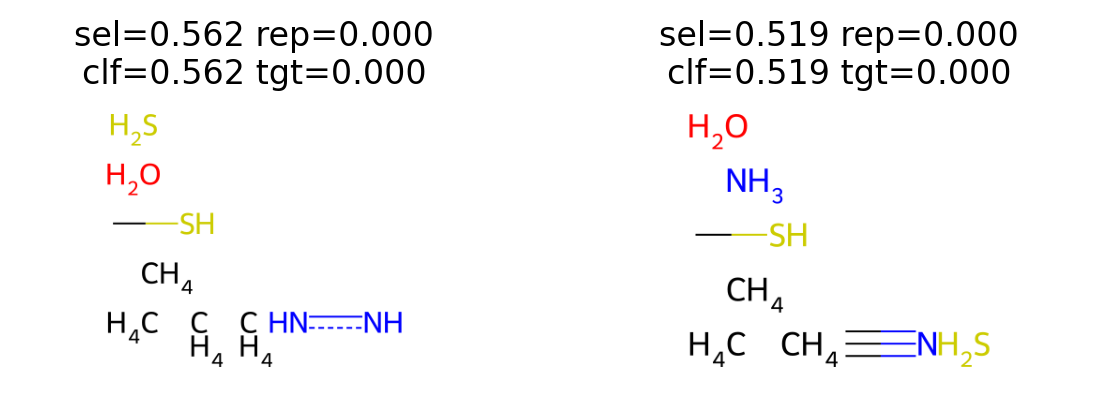

[graph 0] phase=1/4 depth=3 remaining_edges=7 step_time=0m 25.0s eta=2m 55.3s
generated=344 feasible=77 retained=2 tried=876
best_score=0.452 best_target_score=0.000 best_selection_score=0.452 best_repulsion=0.000
target_lambda=0.500 repulsion_lambda=0.000 beam_limit=2


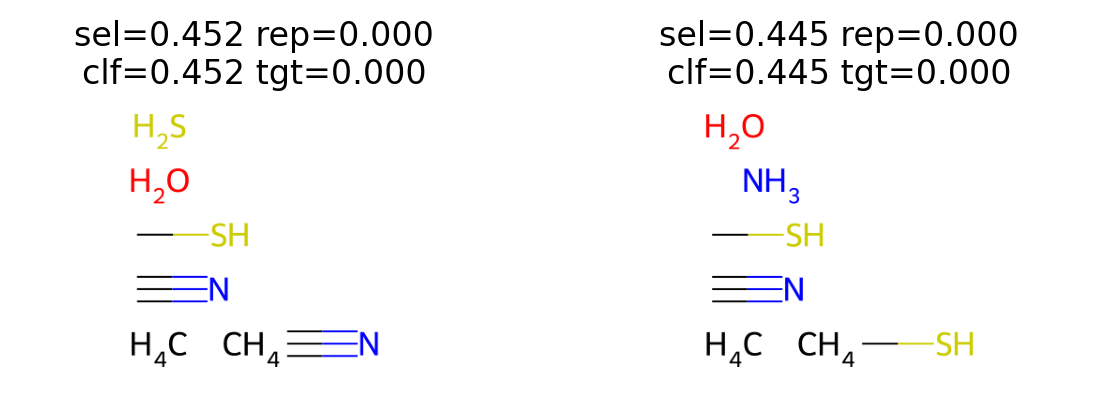

[graph 0] phase=1/4 depth=4 remaining_edges=6 step_time=0m 21.7s eta=2m 10.4s
generated=336 feasible=37 retained=2 tried=1212
best_score=0.403 best_target_score=0.000 best_selection_score=0.403 best_repulsion=0.000
target_lambda=0.500 repulsion_lambda=0.000 beam_limit=2


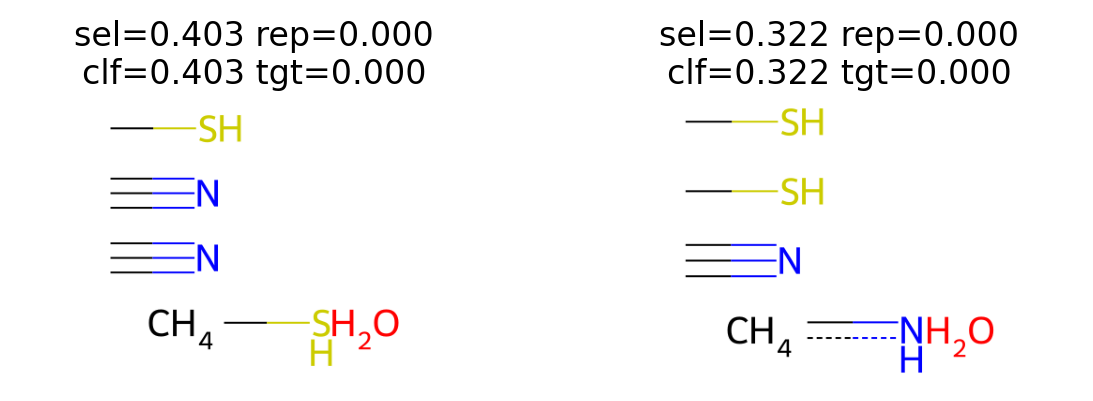

[graph 0] phase=1/4 depth=5 remaining_edges=5 step_time=0m 18.4s eta=1m 31.9s
generated=328 feasible=20 retained=2 tried=1540
best_score=0.369 best_target_score=0.000 best_selection_score=0.369 best_repulsion=0.000
target_lambda=0.500 repulsion_lambda=0.000 beam_limit=2


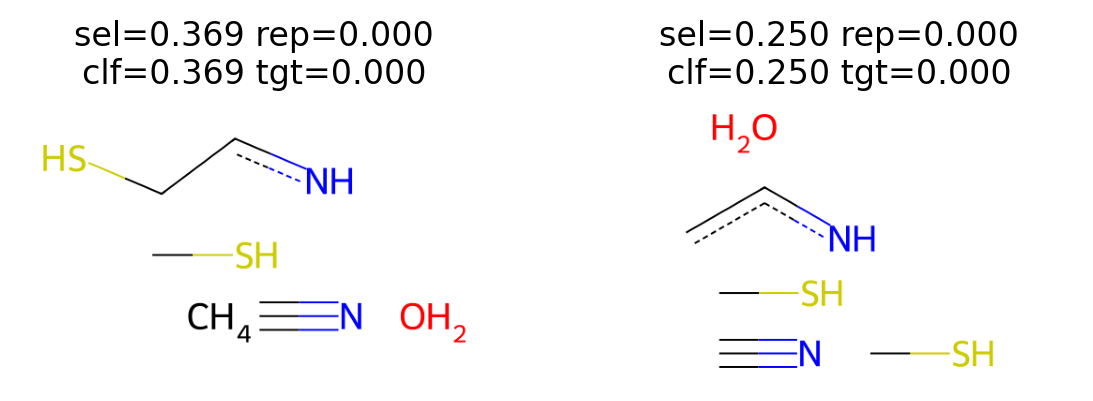

[graph 0] phase=1/4 depth=6 remaining_edges=4 step_time=0m 20.2s eta=1m 20.7s
generated=320 feasible=14 retained=2 tried=1860
best_score=0.335 best_target_score=0.000 best_selection_score=0.335 best_repulsion=0.000
target_lambda=0.500 repulsion_lambda=0.000 beam_limit=2


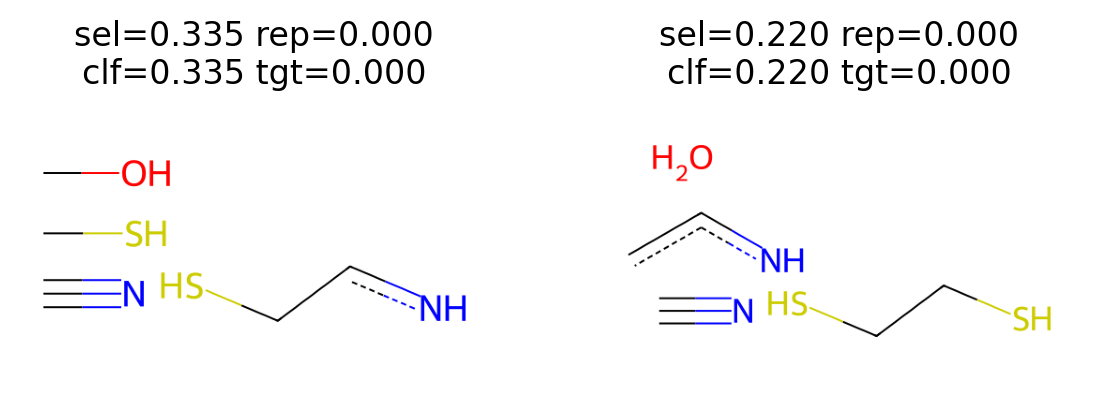

[graph 0] phase=1/4 depth=7 remaining_edges=3 step_time=0m 20.4s eta=1m 1.3s
generated=312 feasible=4 retained=2 tried=2172
best_score=0.466 best_target_score=0.000 best_selection_score=0.466 best_repulsion=0.000
target_lambda=0.500 repulsion_lambda=0.000 beam_limit=2


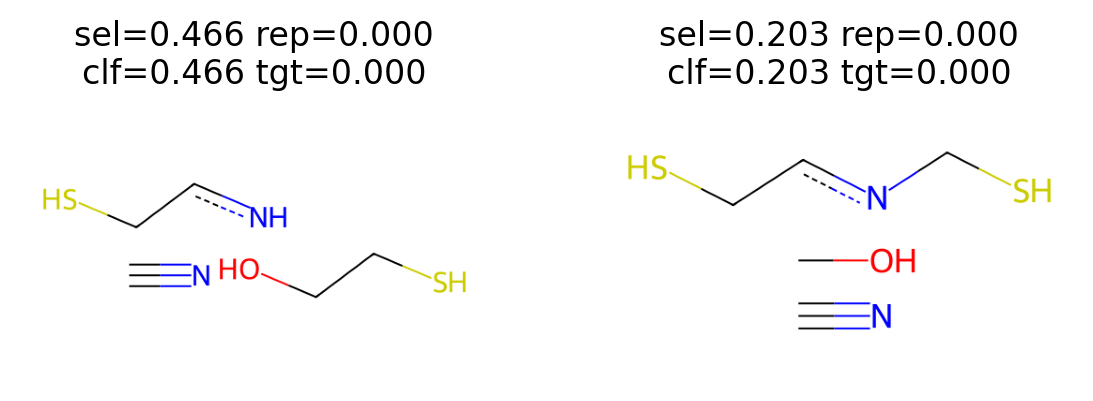

[graph 0] phase=1/4 depth=8 remaining_edges=2 step_time=0m 25.7s eta=0m 51.4s
generated=304 feasible=1 retained=1 tried=2476
best_score=0.278 best_target_score=0.000 best_selection_score=0.278 best_repulsion=0.000
target_lambda=0.500 repulsion_lambda=0.000 beam_limit=2


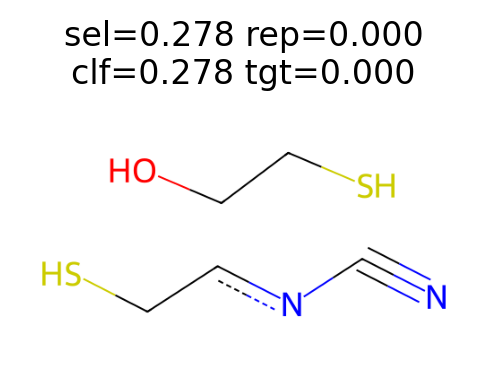

[graph 0] phase=1/4 depth=9 remaining_edges=1 step_time=0m 21.6s eta=0m 21.6s
generated=148 feasible=0 retained=0 tried=2624
best_score=None best_target_score=None best_selection_score=None best_repulsion=0.000
target_lambda=0.500 repulsion_lambda=0.000 beam_limit=2
[graph 0] fallback=1/3 rollback_steps=2 to_depth=6 beam_limit=3
[graph 0] phase=2/4 beam_limit=3 fallback=1/3
[graph 0] phase=2/4 depth=7 remaining_edges=3 step_time=0m 38.1s eta=1m 54.2s
generated=312 feasible=4 retained=3 tried=2936
best_score=0.466 best_target_score=0.000 best_selection_score=0.297 best_repulsion=0.843
target_lambda=0.500 repulsion_lambda=0.200 beam_limit=3


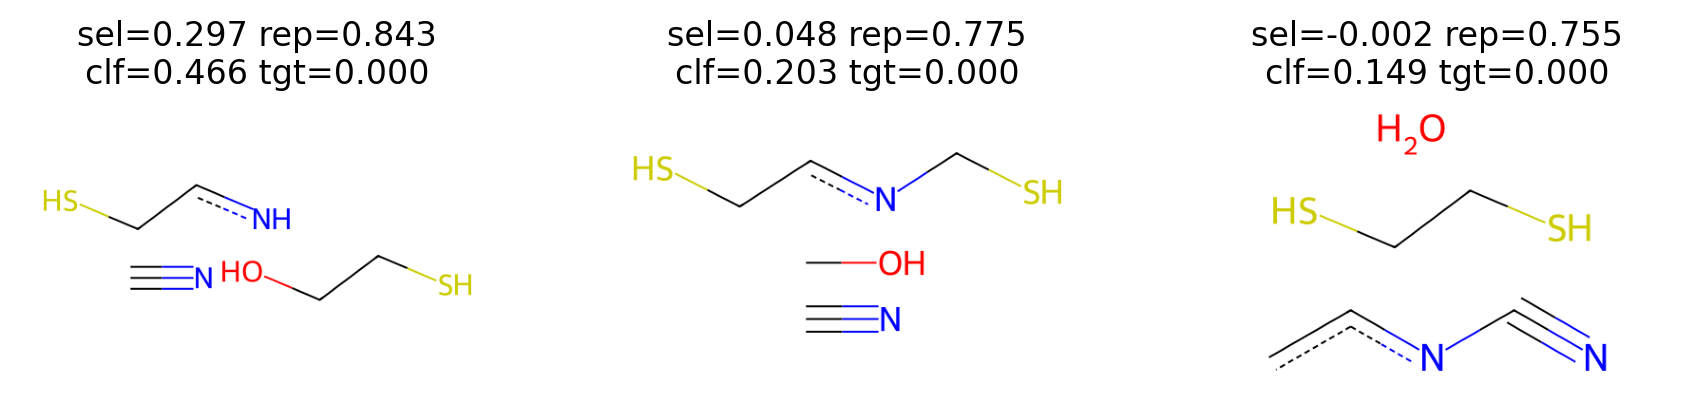

[graph 0] phase=2/4 depth=8 remaining_edges=2 step_time=1m 3.9s eta=2m 7.8s
generated=456 feasible=1 retained=0 tried=3392
best_score=None best_target_score=None best_selection_score=None best_repulsion=0.000
target_lambda=0.500 repulsion_lambda=0.200 beam_limit=3
[graph 0] fallback=2/3 rollback_steps=4 to_depth=3 beam_limit=5
[graph 0] phase=3/4 beam_limit=5 fallback=2/3
[graph 0] phase=3/4 depth=4 remaining_edges=6 step_time=0m 33.2s eta=3m 19.4s
generated=336 feasible=37 retained=5 tried=3728
best_score=0.403 best_target_score=0.000 best_selection_score=0.224 best_repulsion=0.598
target_lambda=0.500 repulsion_lambda=0.300 beam_limit=5


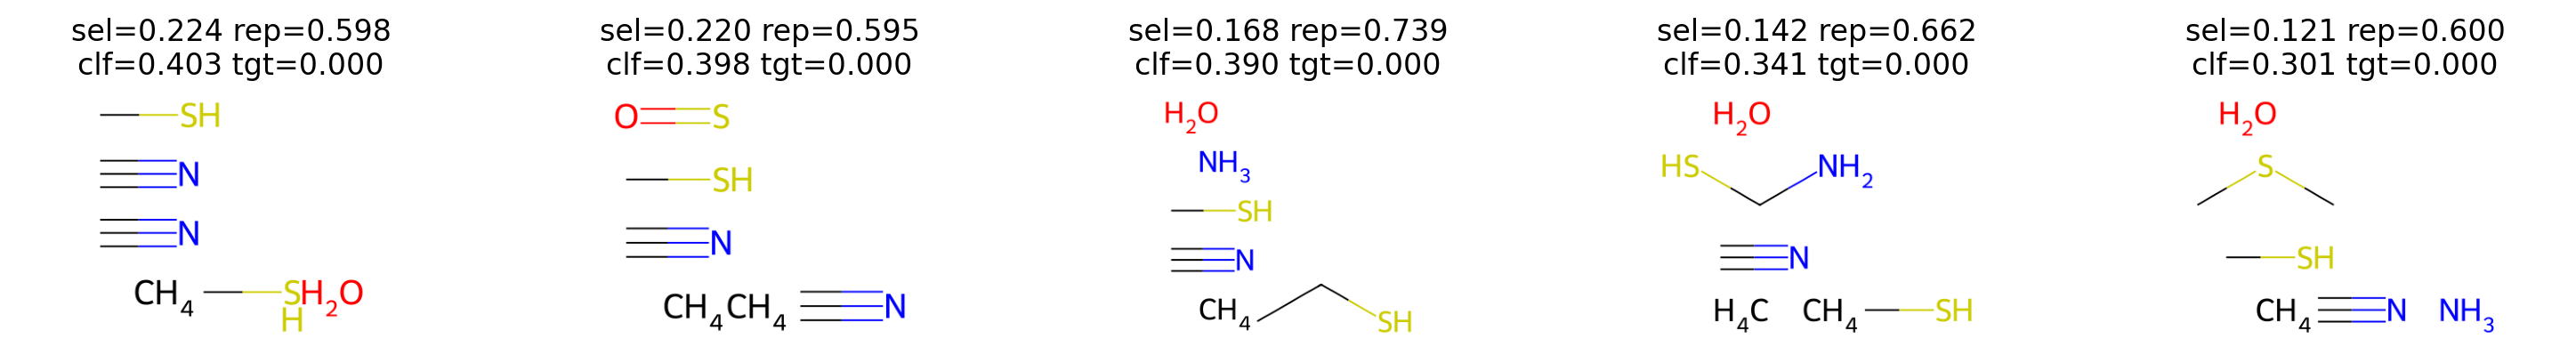

[graph 0] phase=3/4 depth=5 remaining_edges=5 step_time=1m 18.5s eta=6m 32.7s
generated=820 feasible=63 retained=5 tried=4548
best_score=0.593 best_target_score=0.000 best_selection_score=0.368 best_repulsion=0.749
target_lambda=0.500 repulsion_lambda=0.300 beam_limit=5


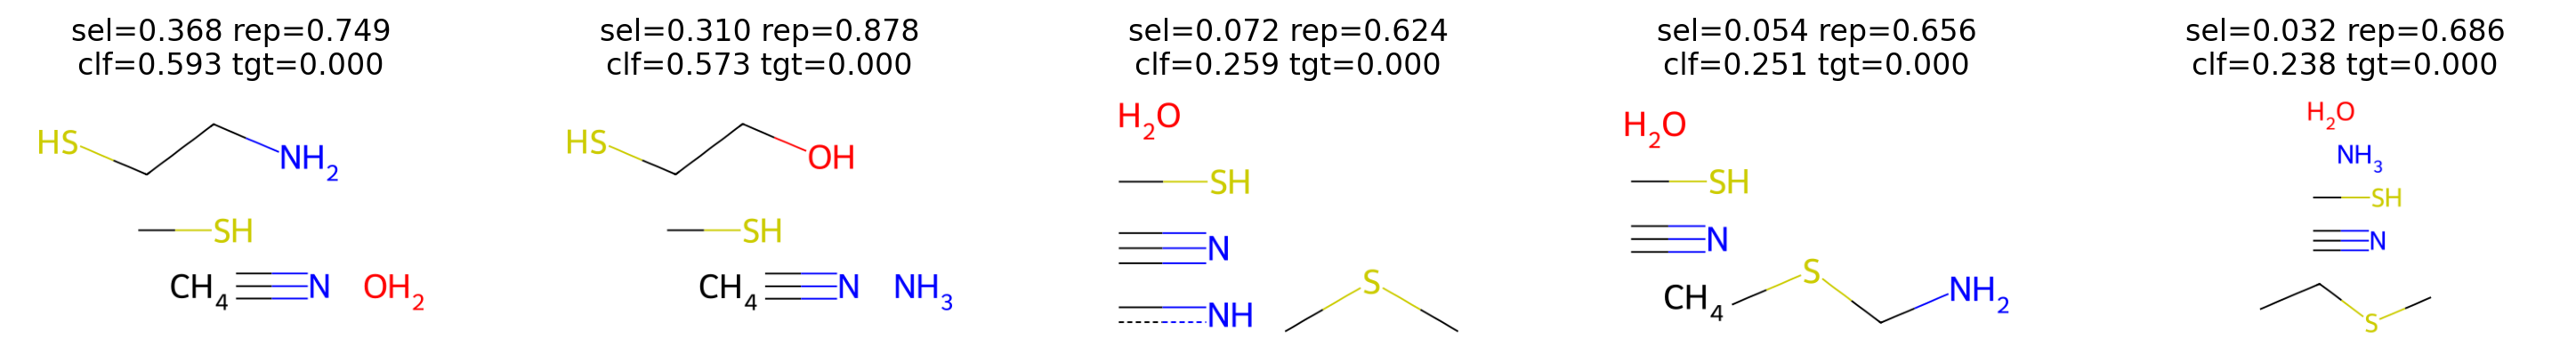

[graph 0] phase=3/4 depth=6 remaining_edges=4 step_time=2m 2.7s eta=8m 10.9s
generated=800 feasible=55 retained=5 tried=5348
best_score=0.632 best_target_score=0.000 best_selection_score=0.371 best_repulsion=0.870
target_lambda=0.500 repulsion_lambda=0.300 beam_limit=5


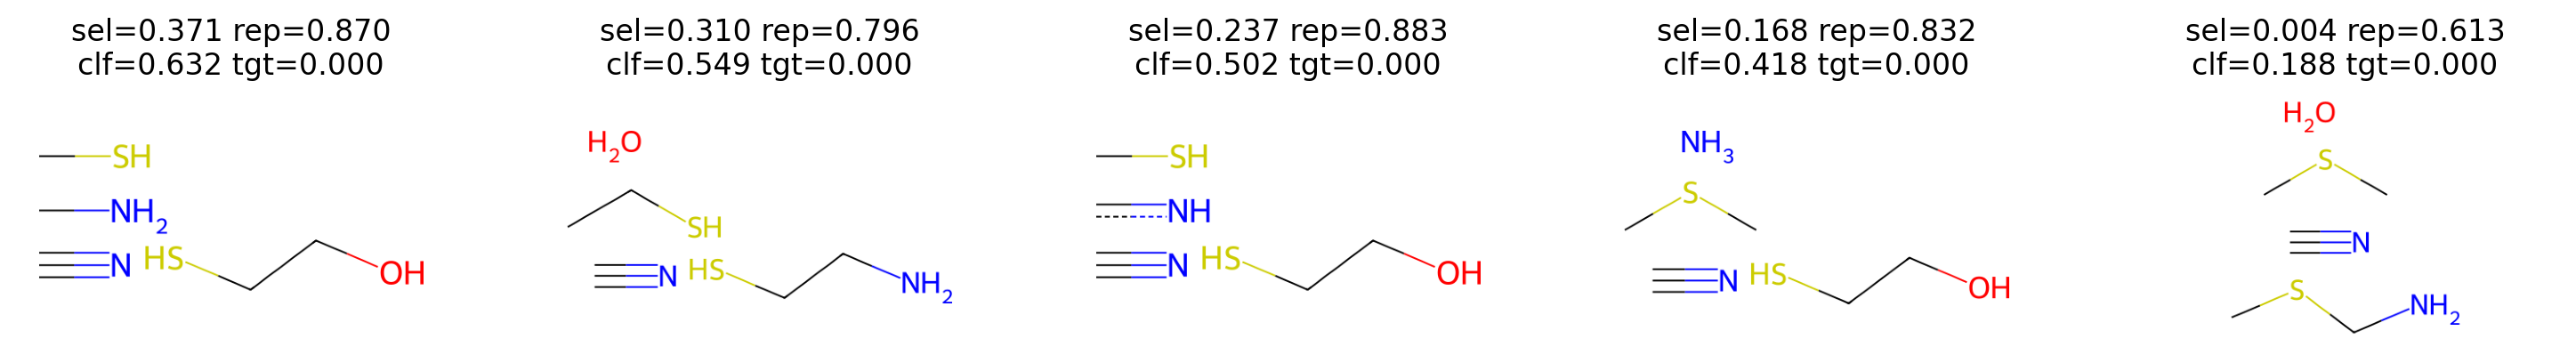

[graph 0] phase=3/4 depth=7 remaining_edges=3 step_time=2m 54.4s eta=8m 43.1s
generated=780 feasible=33 retained=5 tried=6128
best_score=0.657 best_target_score=0.000 best_selection_score=0.388 best_repulsion=0.896
target_lambda=0.500 repulsion_lambda=0.300 beam_limit=5


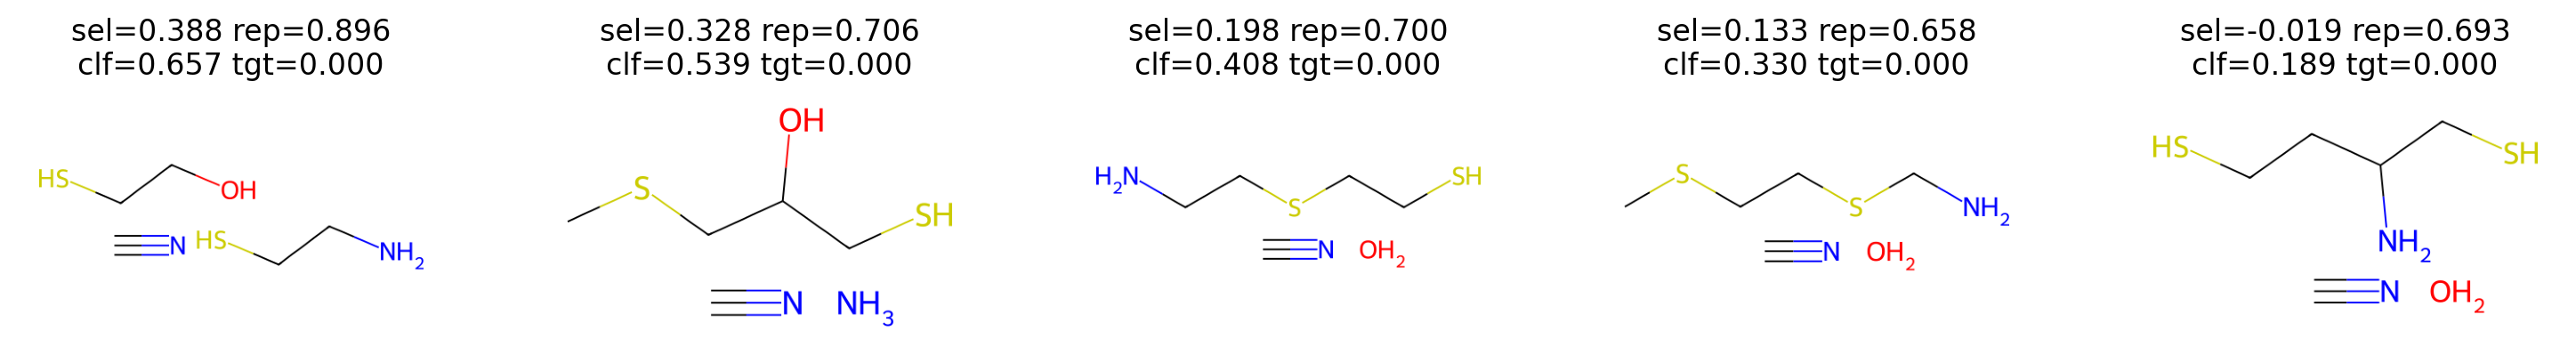

[graph 0] phase=3/4 depth=8 remaining_edges=2 step_time=3m 11.6s eta=6m 23.3s
generated=760 feasible=12 retained=5 tried=6888
best_score=0.518 best_target_score=0.000 best_selection_score=0.310 best_repulsion=0.695
target_lambda=0.500 repulsion_lambda=0.300 beam_limit=5


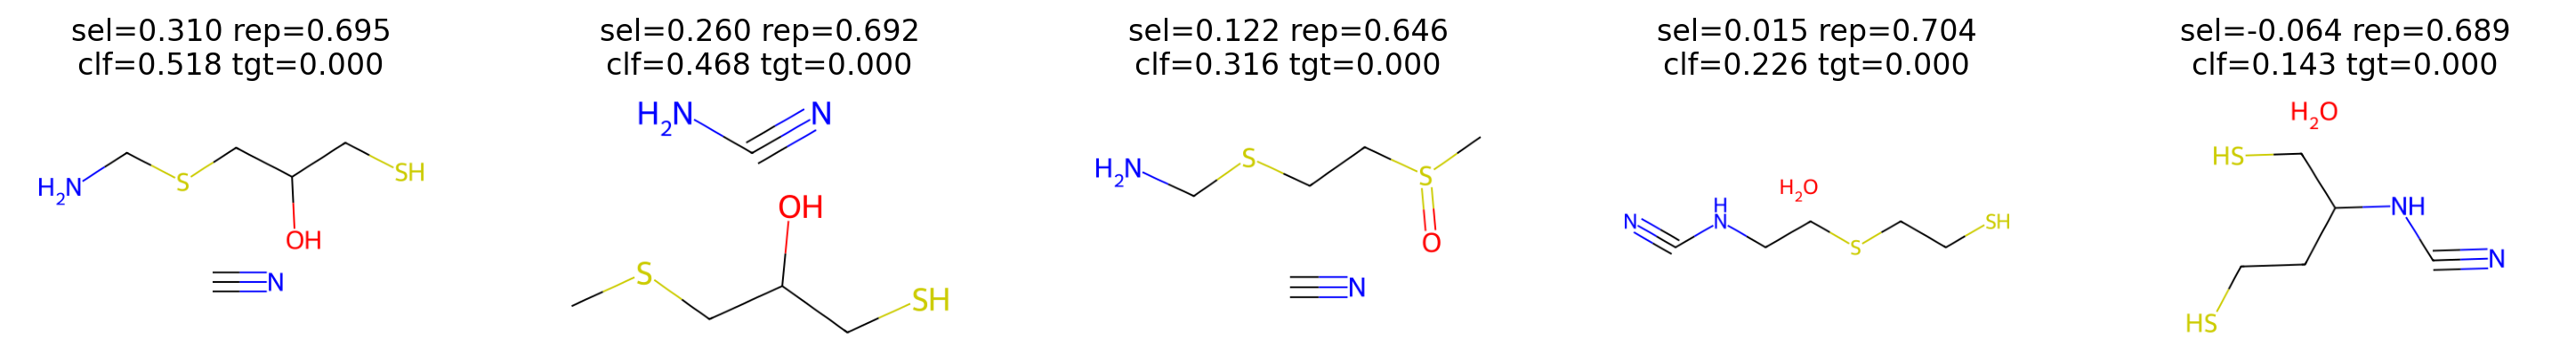

[graph 0] phase=3/4 depth=9 remaining_edges=1 step_time=3m 29.0s eta=3m 29.0s
generated=740 feasible=5 retained=4 tried=7628
best_score=0.477 best_target_score=0.000 best_selection_score=0.272 best_repulsion=0.682
target_lambda=0.500 repulsion_lambda=0.300 beam_limit=5


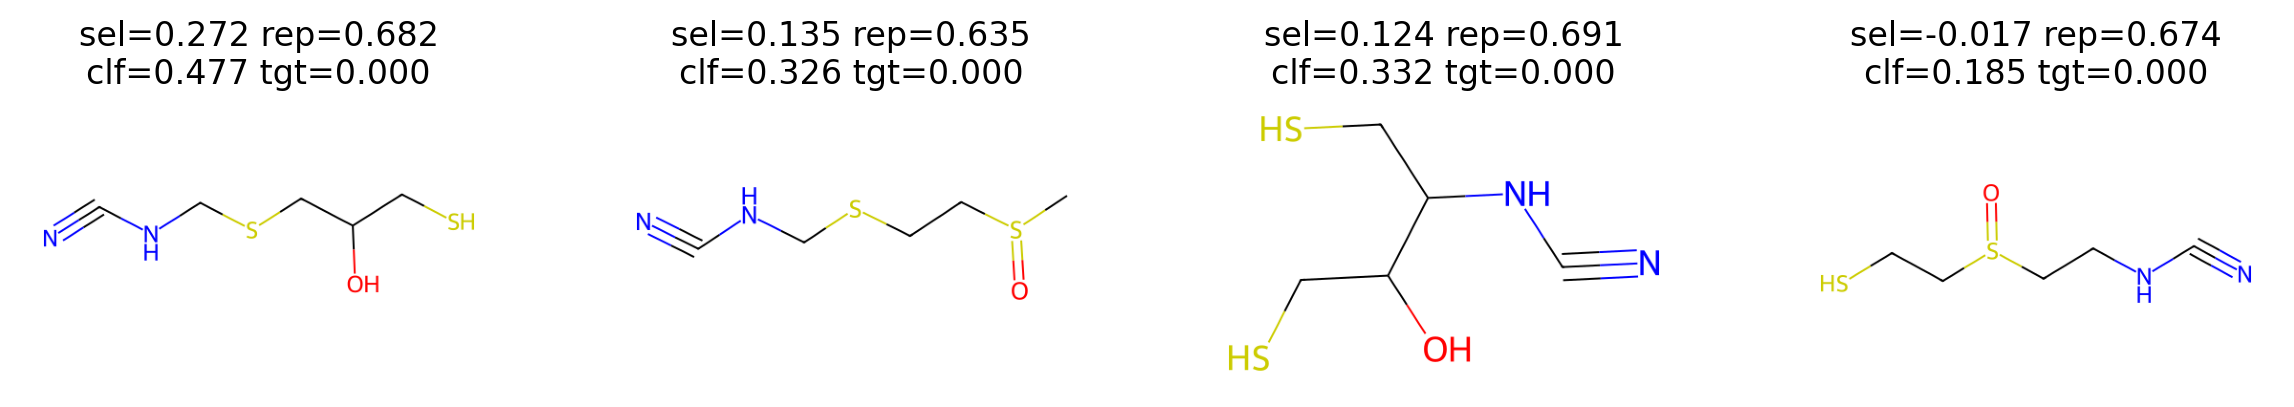

[graph 0] phase=3/4 depth=10 remaining_edges=0 step_time=2m 12.2s eta=0m 0.0s
generated=576 feasible=0 retained=0 tried=8204
best_score=None best_target_score=None best_selection_score=None best_repulsion=0.000
target_lambda=0.500 repulsion_lambda=0.000 beam_limit=5
[graph 0] fallback=3/3 rollback_steps=8 to_depth=1 beam_limit=7
[graph 0] phase=4/4 beam_limit=7 fallback=3/3
[graph 0] phase=4/4 depth=2 remaining_edges=8 step_time=1m 7.9s eta=9m 3.5s
generated=352 feasible=120 retained=7 tried=8556
best_score=0.562 best_target_score=0.000 best_selection_score=0.372 best_repulsion=0.422
target_lambda=0.500 repulsion_lambda=0.450 beam_limit=7


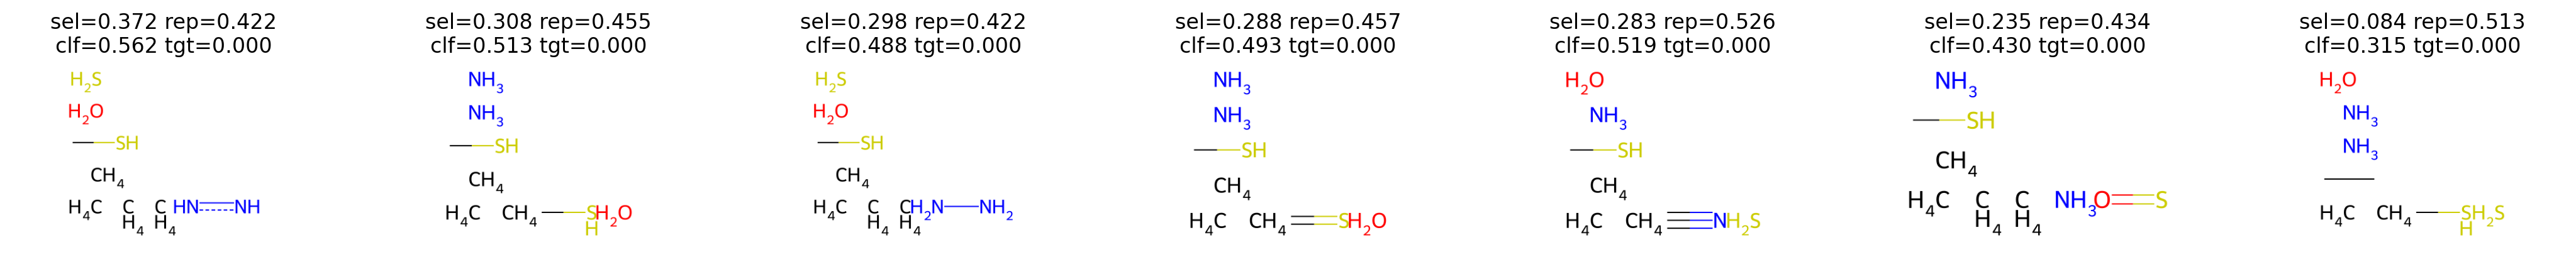

[graph 0] phase=4/4 depth=3 remaining_edges=7 step_time=4m 18.3s eta=30m 8.2s
generated=1204 feasible=330 retained=7 tried=9760
best_score=0.470 best_target_score=0.000 best_selection_score=0.249 best_repulsion=0.491
target_lambda=0.500 repulsion_lambda=0.450 beam_limit=7


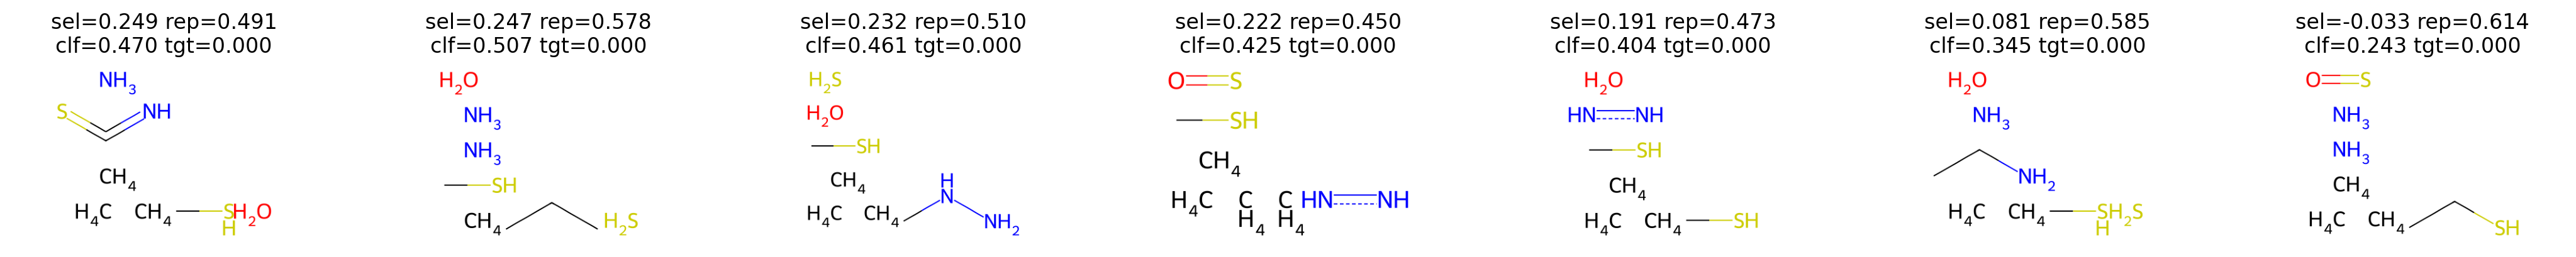

[graph 0] phase=4/4 depth=4 remaining_edges=6 step_time=3m 19.0s eta=19m 54.1s
generated=1176 feasible=252 retained=7 tried=10936
best_score=0.684 best_target_score=0.000 best_selection_score=0.437 best_repulsion=0.548
target_lambda=0.500 repulsion_lambda=0.450 beam_limit=7


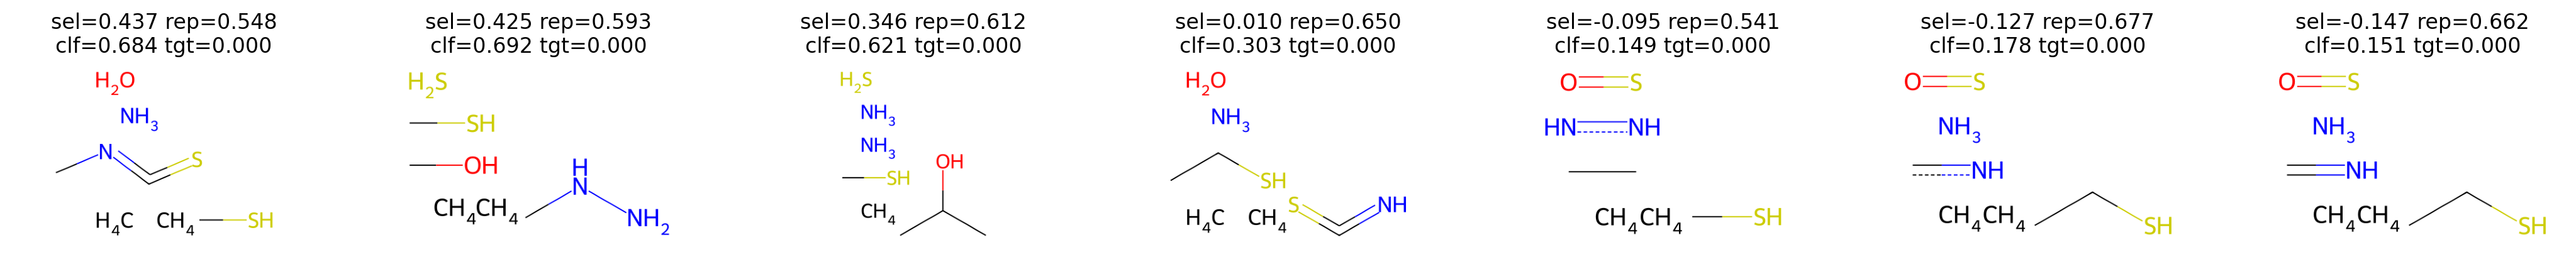

In [ ]:
%%time
generation_path = generator.generate_from_pair(
    graph_a,
    graph_b,
    size_of_edge_removal=0.99,
    n_paths=4,
    target=pair_target,
    target_lambda=0.5,
    return_path=True,
    draw_graphs_fn=lambda graphs, **kwargs: display_graphs(graphs, **kwargs),
)

print(f"generation_path_length = {len(generation_path)}")
if len(generation_path) > 0 : 
    print(f"final_n_edges = {generation_path[-1].number_of_edges()}")
    display_graphs(generation_path, n_graphs_per_line=7)
    print('Generated graph:')
    display_graphs([generation_path[-1]], n_graphs_per_line=1)
    print('Original graphs:')
    display_graphs([graph_a, graph_b], n_graphs_per_line=2)

---